In [1]:
# ====== Editor 可视化：工具函数 ======
import os, re, math, io
from pathlib import Path
from typing import List, Tuple, Optional, Dict

import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# 与你给的示例一致的命令模板（dx, dy, dz, dθ）
COMMANDS = {
    'Forward':       np.array([ 1.0,  0.0,  0.0,  0.0], dtype=np.float32),
    'Rotate Right':  np.array([ 0.0,  0.0,  0.0,  0.5], dtype=np.float32),
    'Rotate Left':   np.array([ 0.0,  0.0,  0.0, -0.5], dtype=np.float32),
    'Back':          np.array([-1.0,  0.0,  0.0,  0.0], dtype=np.float32),
    'Up':            np.array([ 0.0,  0.0, -1.0,  0.0], dtype=np.float32),
    'Down':          np.array([ 0.0,  0.0,  1.0,  0.0], dtype=np.float32),
}
COMMAND_NAMES = list(COMMANDS.keys())
CMD_MATRIX = np.stack([COMMANDS[k] for k in COMMAND_NAMES], axis=0)  # [K,4]

def _read_metadata(run_dir: Path) -> dict:
    p = run_dir / "metadata.json"
    if not p.exists(): 
        return {}
    import json
    try:
        return json.loads(p.read_text("utf-8"))
    except Exception:
        return {}

def _read_frames_sequence(run_dir: Path) -> List[Path]:
    """按顺序返回帧：init.png + step_*.png（不含 goal.png）。"""
    frames_dir = run_dir / "frames"
    if not frames_dir.exists(): 
        return []
    seq = []
    init = frames_dir / "init.png"
    if init.exists():
        seq.append(init)
    # 收集 step_*.png
    step_paths = []
    for p in frames_dir.iterdir():
        if p.is_file() and re.match(r"step_\d{3}\.png$", p.name):
            step_paths.append(p)
    step_paths = sorted(step_paths, key=lambda x: x.name)
    seq.extend(step_paths)
    return seq

def _deltas_from_metadata(run_dir: Path) -> Optional[np.ndarray]:
    """从 metadata.json.frames[].delta 读取 [T,4]。"""
    meta = _read_metadata(run_dir)
    frames = meta.get("frames", [])
    ds = []
    for f in frames:
        # 跳过 INIT
        if f.get("action","INIT") == "INIT":
            continue
        d = f.get("delta")
        if not d: 
            continue
        ds.append([float(d.get('dx',0)), float(d.get('dy',0)), float(d.get('dz',0)), float(d.get('dtheta',0))])
    if not ds: 
        return None
    return np.asarray(ds, dtype=np.float32)

def _deltas_from_candidate_pref(run_dir: Path) -> Optional[np.ndarray]:
    """候选目录优先使用 deltas.npy；否则回落到其 metadata。"""
    npy = run_dir / "deltas.npy"
    if npy.exists():
        arr = np.load(npy)
        if arr.ndim == 3 and arr.shape[0] == 1:  # (1,T,4) → (T,4)
            arr = arr[0]
        return arr.astype(np.float32)
    return _deltas_from_metadata(run_dir)

def _integrate_local(deltas: np.ndarray, theta0: float=np.pi/2, local_frame: bool=True) -> Tuple[np.ndarray, np.ndarray]:
    """
    把 [T,4](dx,dy,dz,dθ) 积分为：
      positions: [T+1, 3]，从(0,0,0)开始
      thetas:    [T+1]，每步先更新θ，再将(dx,dy)绕当前θ旋到世界坐标后累加（与示例一致）
    """
    if deltas is None or len(deltas) == 0:
        return np.zeros((1,3), np.float32), np.array([theta0], np.float32)

    pos = [np.array([0.0,0.0,0.0], dtype=np.float32)]
    ths = [float(theta0)]
    for dx,dy,dz,dth in deltas:
        th = ths[-1] + float(dth)  # 先转向
        if local_frame:
            c, s = math.cos(th), math.sin(th)
            wx = c*dx - s*dy
            wy = s*dx + c*dy
        else:
            wx, wy = dx, dy
        wz = dz
        pos.append(pos[-1] + np.array([wx, wy, wz], np.float32))
        ths.append(th)
    return np.stack(pos,0), np.asarray(ths, np.float32)

def _decode_commands_l2(deltas: np.ndarray) -> List[str]:
    """
    近似把连续 deltas 映射回离散命令（用于标题与帧上文字；没有就尽量贴近）。
    使用 L2 最近原型（COMMANDS），带一点阈值宽容。
    """
    if deltas is None or len(deltas) == 0:
        return []
    # 简单尺度归一，防止dz与dx量纲不同带来的偏置
    scale = np.array([1.0, 1.0, 1.0, 1.0], np.float32)
    names = []
    for v in deltas:
        d = (v / scale)[None, :]           # [1,4]
        dist = np.linalg.norm(d - CMD_MATRIX, axis=1)  # [K]
        k = int(np.argmin(dist))
        names.append(COMMAND_NAMES[k])
    return names

def _load_video_numpy(paths: List[Path]) -> np.ndarray:
    frames = []
    for p in paths:
        im = Image.open(p).convert("RGB")
        frames.append(np.asarray(im))
    return np.stack(frames, 0)  # [F,H,W,3]

def _draw_step_text(img_np: np.ndarray, text: str, xy=(10,10), color=(255,0,0)) -> np.ndarray:
    """在帧上叠字（和你示例一致：红字左上角）。"""
    im = Image.fromarray(img_np.copy())
    draw = ImageDraw.Draw(im)
    try:
        font = ImageFont.load_default()
    except Exception:
        font = None
    draw.text(xy, text, fill=color, font=font)
    return np.asarray(im)

def _axis_with_margin(ax, xs, ys, zs, margin=1.0):
    ax.set_xlim(float(np.min(xs))-margin, float(np.max(xs))+margin)
    ax.set_ylim(float(np.min(ys))-margin, float(np.max(ys))+margin)
    ax.set_zlim(float(np.min(zs))-margin, float(np.max(zs))+margin)

In [2]:
# ====== 主函数：与示例同款布局/样式的动画 ======
def animate_editor_run(
    base_dir: str,
    run_id: str,
    source: str = "candidate",       # "candidate" 或 "final"
    cand_name: str = "cand_000",     # 当 source="candidate" 时使用
    theta0: float = np.pi/2,         # 初始朝向
    local_frame: bool = True,        # 是否在局部坐标中移动（先转向再走）
    fps: int = 2,
    margin: float = 1.0,
    save_mp4: bool = True,
    out_path: str = "output.mp4",
    gt_npy: str = "",                # 可选：GT 的 .npy（[T,4] 或 [N,T,4]）
    gt_row: int = -1                 # 可选：当GT是[N,T,4]时的行号（默认用 run_id 编号）
):
    """
    从 <base_dir>/editor/run_xxx/ 读取帧与deltas，生成和你示例一样的动画：
    - 左：观测/生成帧（叠加 "Step i: <action>"）
    - 右：3D 轨迹 (蓝色 bo- 折线 + 红色方向箭头)
    - 顶部：Sequence: 动作名称 | 动作名称 | ...
    """
    base = Path(base_dir).expanduser().resolve()
    final_dir = base / "editor" / run_id
    if source == "candidate":
        run_dir = final_dir / "candidates" / cand_name
        if not run_dir.exists():
            print(f"[WARN] 找不到 {run_dir}，回退到 final")
            run_dir = final_dir
    else:
        run_dir = final_dir

    # 1) 帧序列（严格对齐 init+steps）
    seq_paths = _read_frames_sequence(run_dir)
    if not seq_paths:
        raise FileNotFoundError(f"未找到帧（init/step_*）: {run_dir}/frames/")
    video = _load_video_numpy(seq_paths)  # [F,H,W,3]
    F = video.shape[0]

    # 2) deltas：candidate 优先 deltas.npy，否则 metadata；final 则从 metadata
    deltas = _deltas_from_candidate_pref(run_dir) if (run_dir != final_dir) else _deltas_from_metadata(run_dir)

    # 3) 轨迹积分（与示例一致：先旋转θ，再走 (dx,dy)）
    positions, thetas = _integrate_local(deltas, theta0=theta0, local_frame=local_frame)  # [T+1,3],[T+1]
    # 对齐帧数：positions 应该和 video 一样是 F（init + T）
    if positions.shape[0] >= F:
        positions = positions[:F]
        thetas = thetas[:F]
    else:
        # 若 positions 偏短，重复最后一个点补齐
        pad = F - positions.shape[0]
        positions = np.vstack([positions, np.repeat(positions[-1:,:], pad, axis=0)])
        thetas = np.concatenate([thetas, np.repeat(thetas[-1:], pad, axis=0)])

    xs, ys, zs = positions[:,0], positions[:,1], positions[:,2]

    # 4) 命令名（用近邻反解），用于标题与帧角标
    cmd_names = _decode_commands_l2(deltas) if deltas is not None else []
    # 如果长度对不上，就截断（或补 "Move"）
    if len(cmd_names) < max(0, F-1):
        cmd_names += ["Move"] * (F-1 - len(cmd_names))
    if len(cmd_names) > max(0, F-1):
        cmd_names = cmd_names[:F-1]

    # 5) 画布布局（与你的示例一致）
    fig = plt.figure(figsize=(12, 6))
    # 顶部标题：Sequence: a | b | c
    seq_title = " | ".join(cmd_names) if cmd_names else "(no decoded commands)"
    fig.suptitle("Sequence: " + seq_title, fontsize=12)
    plt.subplots_adjust(top=0.85)

    from matplotlib import gridspec
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.5])

    # 左：视频帧
    ax1 = fig.add_subplot(gs[0])
    im1 = ax1.imshow(video[0])
    ax1.axis("off")
    ax1.set_title("Generated View")

    # 右：3D 轨迹
    ax2 = fig.add_subplot(gs[1], projection='3d')
    ax2.set_title("3D Trajectory")
    _axis_with_margin(ax2, xs, ys, zs, margin=margin)
    traj_line, = ax2.plot([], [], [], 'bo-', lw=2)  # 样式 bo- 与示例一致
    arrow = ax2.quiver(xs[0], ys[0], zs[0], np.cos(thetas[0]), np.sin(thetas[0]), 0,
                       length=1.0, normalize=True, color='red')

    # 6) init / animate（与示例一致）
    def init():
        # 叠字：Step 0: INIT（可选）
        frame0 = _draw_step_text(video[0], "Step 0: INIT", (10,10), (255,0,0))
        im1.set_data(frame0)
        traj_line.set_data([], [])
        traj_line.set_3d_properties([])
        return im1, traj_line, arrow

    def animate(i):
        nonlocal arrow
        # 帧 i 的文字：i==0→INIT；i>=1→命令名
        if i == 0:
            text = "Step 0: INIT"
        else:
            text = f"Step {i}: {cmd_names[i-1] if i-1 < len(cmd_names) else 'Move'}"
        frame = _draw_step_text(video[i], text, (10,10), (255,0,0))
        im1.set_data(frame)

        traj_line.set_data(xs[:i+1], ys[:i+1])
        traj_line.set_3d_properties(zs[:i+1])

        # 更新朝向箭头（红色）
        try:
            arrow.remove()
        except Exception:
            pass
        dx = float(np.cos(thetas[i])); dy = float(np.sin(thetas[i])); dz = 0.0
        arrow = ax2.quiver(xs[i], ys[i], zs[i], dx, dy, dz, length=1.0, normalize=True, color='red')
        return im1, traj_line, arrow

    anim = animation.FuncAnimation(fig, animate, init_func=init,
                                   frames=F, interval=int(1000/max(1,fps)), blit=False)

    if save_mp4:
        # 优先 ffmpeg，否则回退 GIF（Pillow）
        try:
            writer = animation.FFMpegWriter(fps=fps, bitrate=2000)
            anim.save(out_path, writer=writer)
            print(f"[OK] MP4 saved → {out_path} (ffmpeg)")
        except Exception as e:
            print(f"[WARN] ffmpeg 不可用：{e}；改用 GIF（PillowWriter）")
            gif_out = os.path.splitext(out_path)[0] + ".gif"
            anim.save(gif_out, writer=animation.PillowWriter(fps=fps))
            print(f"[OK] GIF saved → {gif_out}")
    else:
        plt.show()

[OK] MP4 saved → output12.mp4 (ffmpeg)


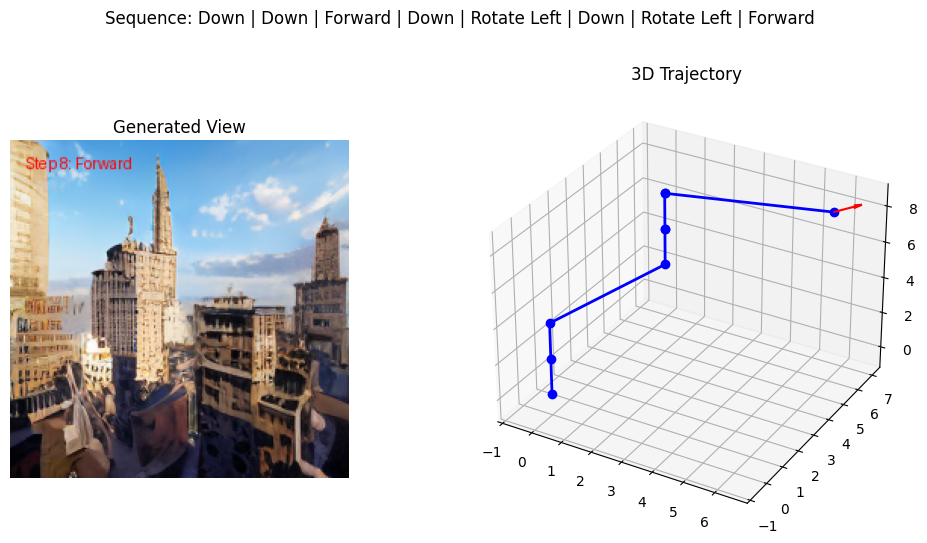

In [3]:
animate_editor_run(
    base_dir="/data1/tpz/nwm-main/results/nwm_cdit_airvln_16/airvln_16/CEM_N10_K10_RS1_rep3_OPT1/",
    run_id="run_012",
    source="candidate",           # 或 "final"
    cand_name="cand_000",         # candidate 时有效
    theta0=np.pi/2,               # 初始朝上
    local_frame=True,             # 与你的 update_position 行为一致
    fps=2,
    margin=1.0,
    save_mp4=True,
    out_path="output12.mp4",
)